# SWOT PIXC Flood Monitoring - Quy Nhon, Vietnam

_Authors: Sabrine Amzil (SERTIT), Thomas Ledauphin (SERTIT), Hervé Yésou (SERTIT), Thomas Altenburger (SERTIT), Mathilde Siméon (CNES), Damien Desroches (CNES)_
 
### Context
Between October and December 2025, heavy rainfall and typhoon events affected central Vietnam, causing widespread flooding and significant damage across the region.

In this practical session, we will explore how SWOT L2 HR PIXC observations can be used to monitor flooding over central Vietnam. We will first create an animation to visualize the spatiotemporal evolution of the observed water surface and height. We will then process PIXC observations in NetCDF format to extract water pixels over a specific area and compare the resulting flood extent with the Copernicus Emergency Management Service (CEMS) Rapid Mapping (RM) product derived from ICEYE radar imagery.

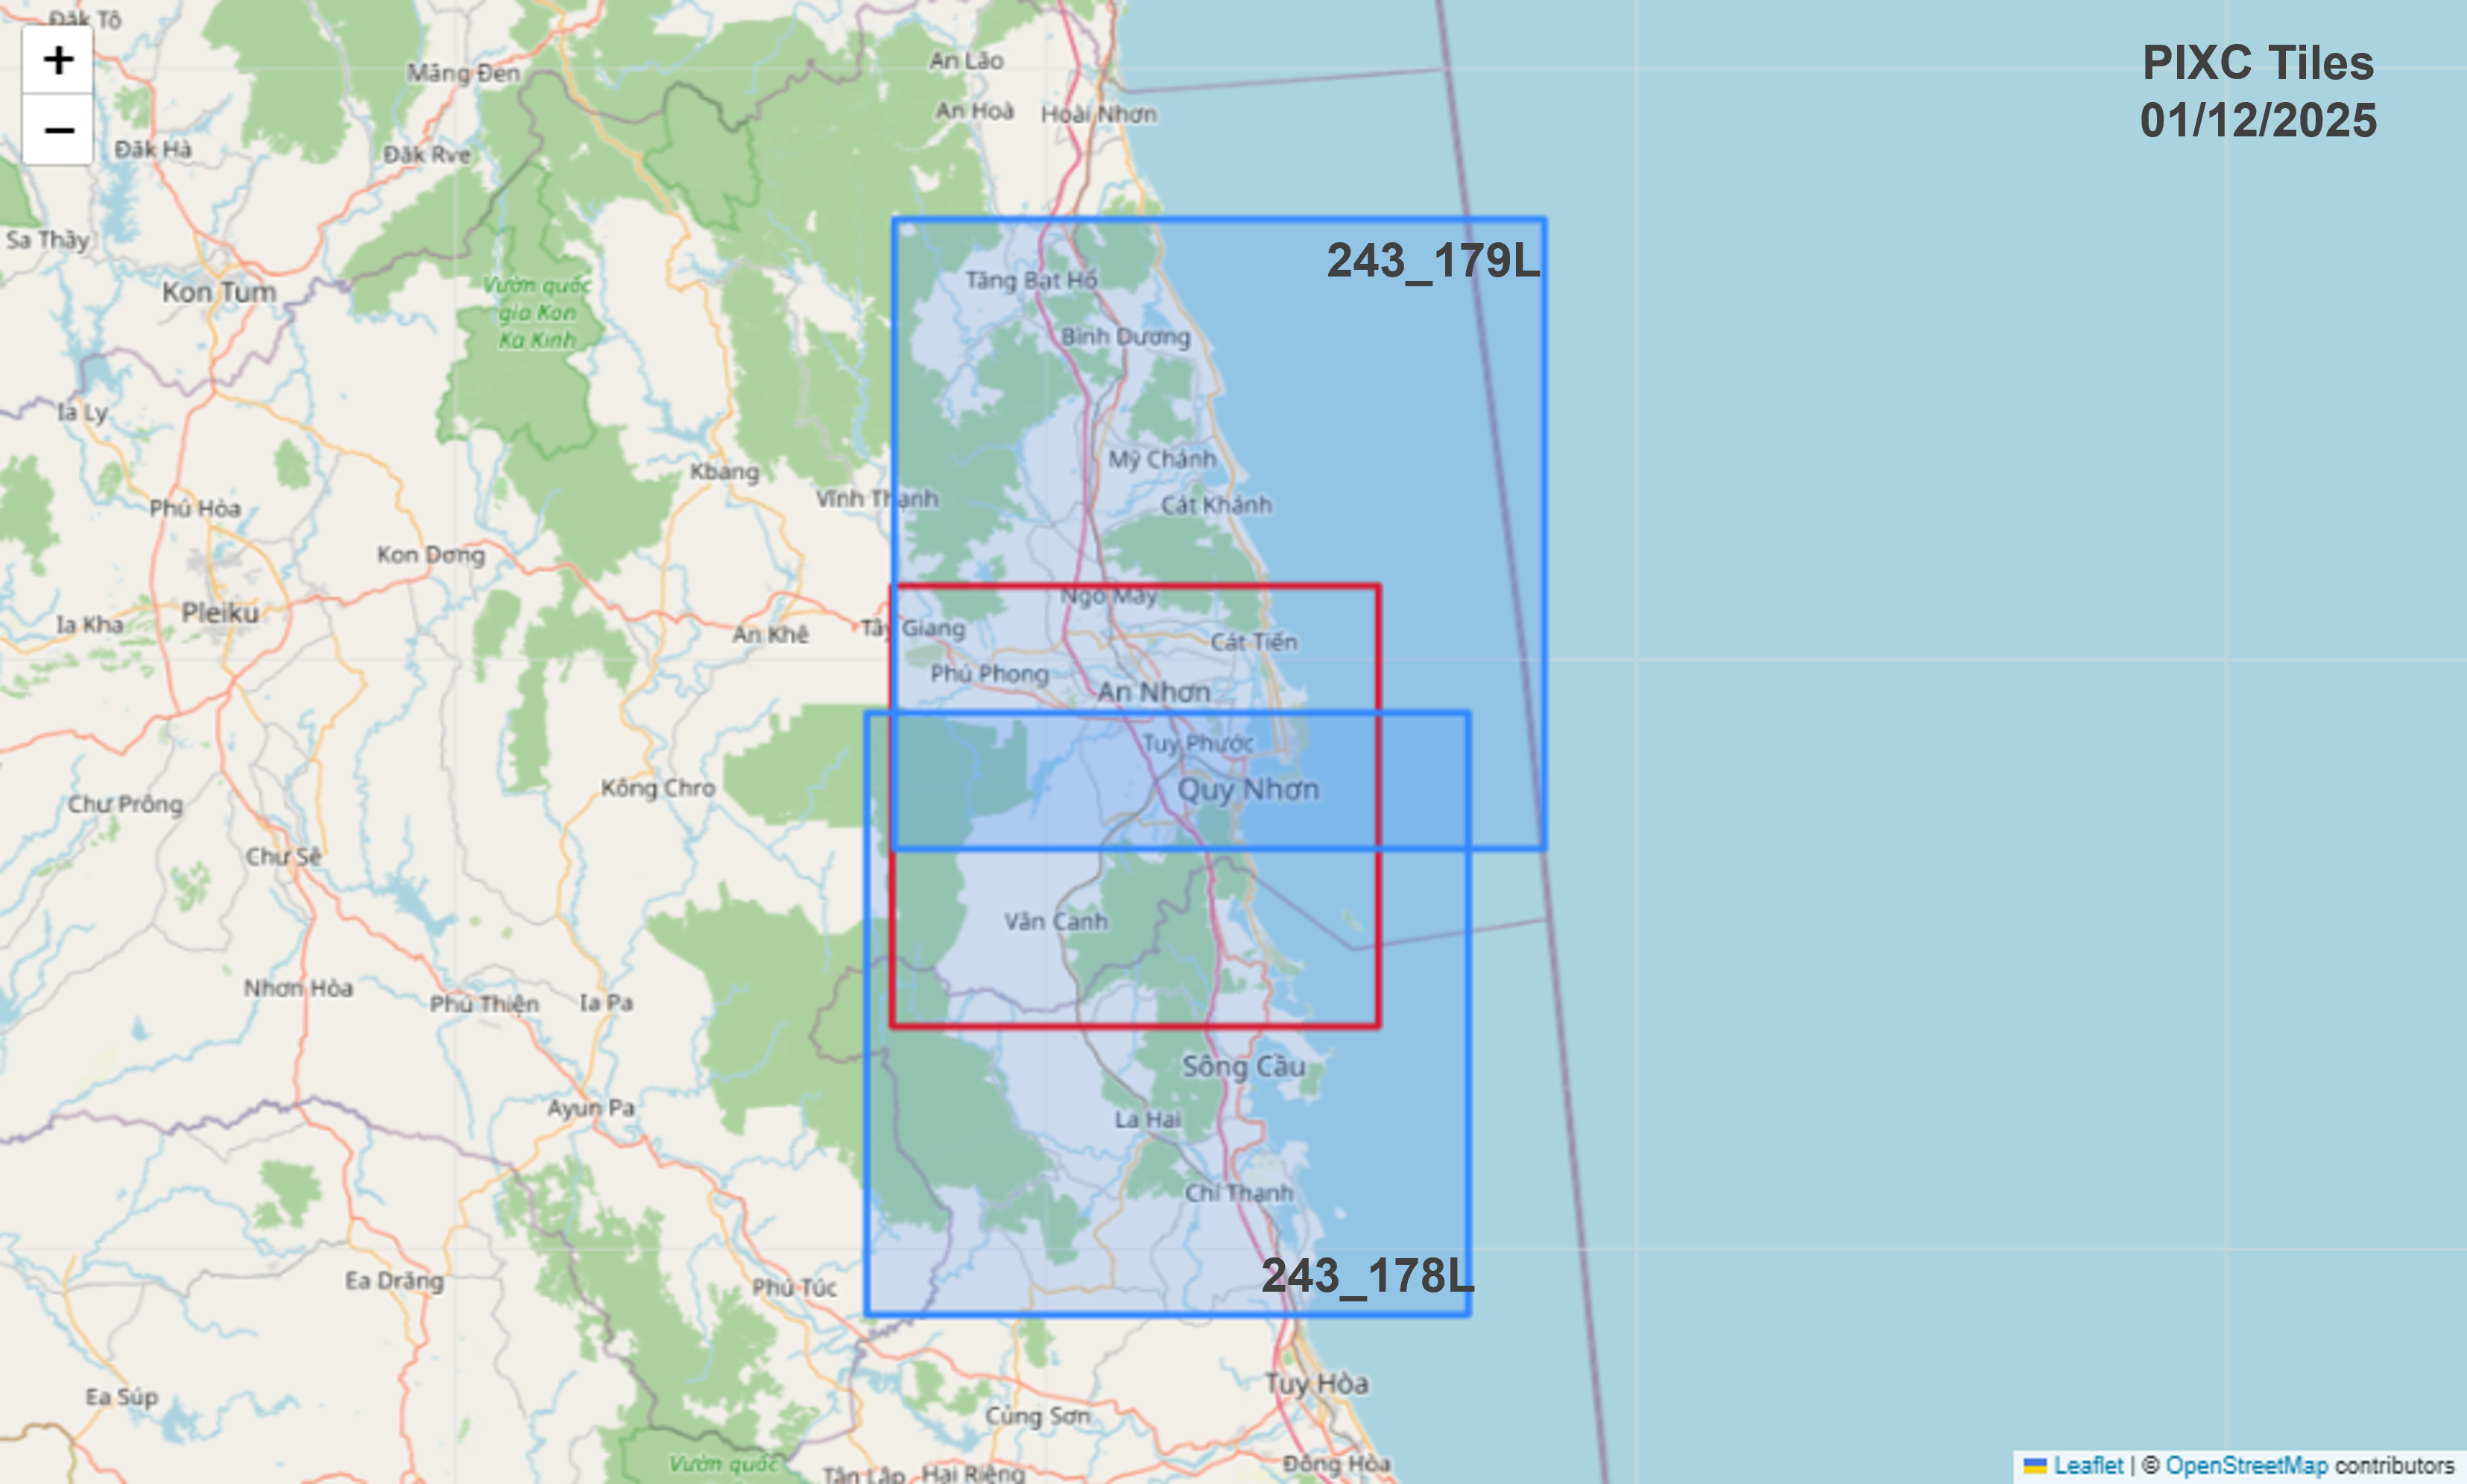

Figure 1: SWOT PIXC tiles (243_178L, 243_179L) covering Quy Nhon region. If Figure is not displayed, see slide 5.

### Requirements
1. Download the directory "PIXC_Vietnam_flooding" (in .zip format) using the seafile link on slide 10
and move them in the work directory
2. Select the kernel `swot-flood` (Not needed if you work on Mybinder)
3. Run the notebook


### Content
* [I. Setup](#I.-Setup)
* [II. List SWOT observations for a specific area](#II.-List-SWOT-observations-for-a-specific-area)
* [III. Visualizing Water Surface Changes Over Time](#III.-Visualizing-Water-Surface-Changes-Over-Time)
* [VI. Analysis of a Flood Event Using SWOT and CEMS-RM](#VI.-Analysis-of-a-Flood-Event-Using-SWOT-and-CEMS-RM)


## I. Setup

In [ ]:
# Unzip downloaded directory in work
!unzip work/PIXC_Vietnam_flooding.zip -d work

In [ ]:
import datetime
import glob
import io
import os
import re
from collections import defaultdict

import geopandas as gpd
import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray
import xarray as xr
from IPython.display import HTML
from matplotlib import colormaps
from matplotlib.patches import Patch
from netCDF4 import Dataset
from PIL import Image
from shapely.geometry import Polygon, box
from shapely.geometry import Point, LineString

In [2]:
def get_world_image(bbox):
    '''This function gets world map image from arcgis server, according to bbox
    input: bbox [lonmin, latmin, lonmax, latmax] in EPSG:4326
    '''
    
    xmin, ymin, xmax, ymax = gpd.GeoDataFrame(index=[0,1,2,3], geometry=gpd.points_from_xy([bbox[0],bbox[2],bbox[0],bbox[2]], [bbox[1],bbox[1],bbox[3],bbox[3]]), crs="EPSG:4326").to_crs("EPSG:3857").total_bounds*1E-7
    
  
    ResRef = 2048 / 3
    coor = {"llon": xmin, "llat": ymin, "ulon": xmax, "ulat": ymax}

    DeltaX = float(xmax - xmin)
    DeltaY = float(ymax - ymin)
    ratio_lat_over_lon = DeltaY / DeltaX
    if DeltaX > DeltaY:
        ResX = ResRef
        ResY = int(ResRef * ratio_lat_over_lon)
    elif DeltaX < DeltaY:
        ResX = int(ResRef / ratio_lat_over_lon)
        ResY = ResRef
    else:
        ResX = ResRef
        ResY = ResRef

    # You can check for more server here: https://server.arcgisonline.com/arcgis/rest/services
    server = "https://server.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer"
    
    dpi=200
    fmt="png32"
    basemap_url = f"{server}/export?bbox={xmin}E7%2C{ymin}E7%2C{xmax}E7%2C{ymax}E7%2C&size={ResX},{ResY}&dpi={dpi}&format={fmt}&f=image"
    

    resp = requests.get(basemap_url)
 
    im = Image.open(io.BytesIO(resp.content))

    return im

## II. List SWOT observations for a specific area

In [ ]:
# Define a search area
ymin = 13.5
ymax = 14.1

xmin = 108.8
xmax = 109.38

# output folder
output_folder = r'./work/PIXC_Vietnam_flooding/OUTPUT'

In [ ]:
# Folder with pixc products  
files = glob.glob('./work/PIXC_Vietnam_flooding/PIXC/SWOT_L2_HR_PIXC_*.nc')  
files

## III. Visualizing Water Surface Changes Over Time

### Load interesting portions of data, being careful to use only pixels classified as water

In [5]:
# Load and group the relevant portions of data by cycle and pass
grouped = defaultdict(lambda: {
    "lon": [],
    "lat": [],
    "height": [],
    "date": None
})

files = sorted(files)

for i, name in enumerate(files):
    # Extract cycle and pass numbers from the file name
    basename = os.path.basename(name)
    parts = basename.split("_")

    cycle = parts[4]
    pass_num = parts[5]
    key = (cycle, pass_num)

    # Open the dataset to retrieve the acquisition date (used for display only)
    ds_meta = xr.open_dataset(name)
    date = str(ds_meta.time_granule_start)
    # Open the PIXC
    ds = xr.open_dataset(name, group='pixel_cloud')
    
    # Load the variables needed for the analysis
    height = ds["height"][:]
    classification = ds["classification"][:]
    flag = ds["bright_land_flag"][:]
    latitude = ds["latitude"][:]
    longitude = ds["longitude"][:]

    # Select point cloud classified as water (class 3 for 'water near land' & 4 for 'open water')
    ind_water = (classification == 3) | (classification == 4) 
    
    # Select point cloud located within the study area and exclude bright land PIXC points
    ind_area = (
        (latitude > ymin) &
        (latitude < ymax) &
        (longitude > xmin) &
        (longitude < xmax)  &
        (flag == 0)
)
    # Combine the water and spatial selection criteria
    index = ind_water & ind_area

    # Store the selected longitude, latitude, and height values grouped by cycle and pass
    grouped[key]["lon"].append(longitude[index].values)
    grouped[key]["lat"].append(latitude[index].values)
    grouped[key]["height"].append(height[index].values)

    # Store the acquisition date once for each cycle/pass combination
    if grouped[key]["date"] is None:
        grouped[key]["date"] = str(date)[:10]

In [6]:
# Combine all selected data for each cycle/pass combination into individual snapshots 
# and creates a corresponding label for display or visualization
snapshots = []
labels = []

for (cycle, pass_num) in sorted(grouped.keys(), key=lambda x: (int(x[0]), int(x[1]))):

    lon = np.concatenate(grouped[(cycle, pass_num)]["lon"])
    lat = np.concatenate(grouped[(cycle, pass_num)]["lat"])
    h = np.concatenate(grouped[(cycle, pass_num)]["height"])

    snapshots.append((lon, lat, h))

    labels.append(
        f"Cycle {cycle} - Pass {pass_num} - {grouped[(cycle, pass_num)]['date']}"
    )

### Plot the animation

matplotlib ArtistAnimation allows to loop over a list of images (snapshots) in an animated plot.

In [7]:
# delay in seconds between images
delay=1

In [8]:
fig = plt.figure(0,figsize = (15,10))
ax = fig.add_subplot(111)

# Background
background = plt.imshow(get_world_image([xmin, ymin, xmax, ymax]),extent=[xmin, xmax, ymin,ymax], aspect="equal")
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in each frame

container = []
for i in range(len(snapshots)):
    im= plt.scatter(snapshots[i][0],snapshots[i][1], c=snapshots[i][2],s=0.005,animated=True,vmin=0,vmax=100)
    txt = plt.text(0.5, 1.01, f"SWOT PIXC Observations (water class 3 & 4) - {labels[i]}", horizontalalignment='center', verticalalignment='bottom', transform=ax.transAxes)
    
    container.append([txt,im,background])

plt.colorbar(im,label="Height [m]")
    
ani = animation.ArtistAnimation(fig, container,interval=delay*1e3)

plt.close(0)

HTML(ani.to_jshtml())

### Analysis
We can see the rivers enlarging and many water detected over the city

### Saving the animation
It is possible to save the animation as a video or a gif image. 

TIP: for windows, use writer=animation.PillowWriter(fps=30) )

In [ ]:
# Save in a path
#output_file = os.path.join(output_folder, "animation_pixc_quynhon_243_178L_179L.gif")
#ani.save(output_file, writer="imagemagick", fps=1./delay)

## VI. Analysis of a Flood Event Using SWOT and CEMS-RM

### 1. Manipulation of a SWOT PIXC observation in netCDF format

In [ ]:
# Create a dictionary where each cycle number is associated with a list of file paths
pixc_dict = defaultdict(list)
# Loop through all files
for path in files:
    # Extract the filename from the full file path
    filename = os.path.basename(path)
    # Split the filename into parts using "_" as a separator
    parts = filename.split("_")
    # Extract the cycle number from the fifth element of the filename
    cycle_number = int(parts[4])
    # Add the file path to the list corresponding to its cycle number
    pixc_dict[cycle_number].append(path)
# Sort the dictionary by cycle number and convert it back to a regular dictionary
pixc_dict = dict(sorted(pixc_dict.items()))
pixc_dict

In [ ]:
# Select the cycle number to analyze
cyc = 42
# Create an empty list to store the datasets for this cycle
pixc_datasets = []
for file in pixc_dict[cyc]:
    print(os.path.basename(file))
    # Open the NetCDF file
    ds = Dataset(file)
    pixc_datasets.append(ds)

# Display the variables available in the "pixel_cloud" group
# of the first dataset
pixc_datasets[0]["pixel_cloud"].variables

In [12]:
# Extract pixel-level variables and tile metadata from all PIXC files
# belonging to the selected cycle, then concatenate the data into single arrays.

# Initialize empty lists to store pixel_cloud variables
height = []
sig0 = []
classification = []
azimuth_index = []
range_index = []
pixel_area = []
incidence = []
latitude = []
longitude = []
cross_track = []

# Initialize an empty list to store information about each tile
tile_info = []
# Loop through all PIXC files belonging to the selected cycle
for file in pixc_dict[cyc]:
    with Dataset(file) as pixc_ds:
        pc = pixc_ds.groups["pixel_cloud"]
        # Extract PIXC variables
        height.append(pc.variables["height"][:])
        sig0.append(pc.variables["sig0"][:])
        classification.append(pc.variables["classification"][:])
        azimuth_index.append(pc.variables["azimuth_index"][:])
        range_index.append(pc.variables["range_index"][:])
        pixel_area.append(pc.variables["pixel_area"][:])
        incidence.append(pc.variables["inc"][:])
        latitude.append(pc.variables["latitude"][:])
        longitude.append(pc.variables["longitude"][:])
        cross_track.append(pc.variables["cross_track"][:])
        # Extract metadata describing the tile
        tile_info.append({
            "tile_name": pixc_ds.getncattr("tile_name"),
            "swath_side": pixc_ds.getncattr("swath_side"),
            "lon_min": pixc_ds.getncattr("geospatial_lon_min"),
            "lon_max": pixc_ds.getncattr("geospatial_lon_max"),
            "lat_min": pixc_ds.getncattr("geospatial_lat_min"),
            "lat_max": pixc_ds.getncattr("geospatial_lat_max"),
            "slc_range_resolution": pixc_ds.getncattr("slc_range_resolution"),
        })

# Concatenate the data from all files into single arrays
height = np.ma.concatenate(height)
sig0 = np.ma.concatenate(sig0)
classification = np.ma.concatenate(classification)
azimuth_index = np.concatenate(azimuth_index)
range_index = np.concatenate(range_index)
pixel_area = np.ma.concatenate(pixel_area)
incidence = np.ma.concatenate(incidence)
latitude = np.ma.concatenate(latitude)
longitude = np.ma.concatenate(longitude)
cross_track = np.ma.concatenate(cross_track)

In [ ]:
# Create a GeoDataFrame containing all PIXC attributes
pixc_gdf = gpd.GeoDataFrame(
    {
        "height": np.asarray(height),
        "sig0": np.asarray(sig0),
        "classification": np.asarray(classification),
        "azimuth_index": np.asarray(azimuth_index),
        "range_index": np.asarray(range_index),
        "pixel_area": np.asarray(pixel_area),
        "incidence": np.asarray(incidence),
        "latitude": np.asarray(latitude),
        "longitude": np.asarray(longitude),
        "cross_track": np.asarray(cross_track),
    },
    geometry=gpd.points_from_xy(
        np.asarray(longitude),
        np.asarray(latitude)
    ),
    crs="EPSG:4326"
)

pixc_gdf.head()

In [ ]:
# Display the tile names covering the study area
tile_names = ", ".join(tile["tile_name"] for tile in tile_info)  
tile_names

#### Clip the PIXC to the study area

In [ ]:
# Clip PIXC to the study area
mask = (
    (pixc_gdf["longitude"] >= xmin) &
    (pixc_gdf["longitude"] <= xmax) &
    (pixc_gdf["latitude"] >= ymin) &
    (pixc_gdf["latitude"] <= ymax)
)
pixc_clip_gdf = pixc_gdf.loc[mask].copy()
print(f"Original PIXC points : {len(pixc_gdf):,}")
print(f"Clipped PIXC points  : {len(pixc_clip_gdf):,}")

In [ ]:
# Save clipped PIXC
output_file = os.path.join(output_folder, "PIXC_clipped.shp")
pixc_clip_gdf.to_file(output_file, driver="ESRI Shapefile")
print(f"Clipped PIXC saved to:\n{output_file}")

#### Plot Surface Classification
##### uint8 classification(points)
     _FillValue: 255
     long_name: classification
     quality_flag: classification_qual
     flag_meanings: land land_near_water water_near_land open_water dark_water low_coh_water_near_land open_low_coh_water
     flag_values: [1 2 3 4 5 6 7]
     comment: Flags indicating water detection results.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Background
ax.imshow(get_world_image([xmin, ymin, xmax, ymax]), extent=[xmin, xmax, ymin, ymax], aspect="equal")

# Clipped PIXC
sc = ax.scatter(
    pixc_clip_gdf["longitude"],
    pixc_clip_gdf["latitude"],
    s=0.002,
    c=pixc_clip_gdf["classification"],
    vmin=0.5,
    vmax=7.5,
    alpha=0.8,
    cmap = matplotlib.colormaps.get_cmap("Dark2").resampled(7)
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_xlabel("Longitude (°)", fontsize=14)
ax.set_ylabel("Latitude (°)", fontsize=14)

ax.set_title(f"{tile_names} - Clipped PIXC - 7 classes", fontsize=16)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()

#### Plot Heights of Water Pixel Clouds


In [ ]:
# Select water pixels --> Classification 3 (water near land) & 4 (open water)
ind_water = pixc_clip_gdf["classification"].isin([3, 4]) 
water_gdf = pixc_clip_gdf.loc[ind_water].copy()
print(f"Number of water pixels: {len(water_gdf):,}")

In [ ]:
# Plot open water pixel heights
fig, ax = plt.subplots(figsize=(12, 8))

# Background
ax.imshow(get_world_image([xmin, ymin, xmax, ymax]), extent=[xmin, xmax, ymin, ymax], aspect="equal")

# Water pixels colored by height
sc = ax.scatter(
    water_gdf.geometry.x,
    water_gdf.geometry.y,
    s=0.005,
    c=water_gdf["height"],
    cmap="viridis",
    vmin=0,
    vmax=100
)

# Keep the study area extent
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

ax.set_title(f"PIXC Water Pixels - Height - 01/12/2025 (cycle 42)")

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Height (m)")

plt.tight_layout()
plt.show()

### 2. Flood detected by Copernicus Emergency Management Rapid Mapping Service (CEMS RM)

In [20]:
# Shapefile of the CEMS area of interest and observed flood with radar imagery
cems_aoi_path = r'./work/CEMS_RM/EMSR848_AOI16_BLP_PRODUCT_areaOfInterestA_v1.shp'
cems_hydro_ref_path = r'./work/CEMS_RM/EMSR848_AOI16_BLP_PRODUCT_hydrographyA_v1.shp'
cems_obs_flood_path = r'./work/CEMS_RM/EMSR848_AOI16_DEL_MONIT01_observedEventA_v1.shp'

In [21]:
# read CEMS area of interest
cems_aoi_gdf = gpd.read_file(cems_aoi_path)

# read CEMS observed flood with radar imagery
cems_obs_flood_gdf = gpd.read_file(cems_obs_flood_path)

# read CEMS reference hydrography
cems_hydro_ref_gdf = gpd.read_file(cems_hydro_ref_path)

In [ ]:
# Plot the area of interest
fig, ax = plt.subplots(figsize=(12, 8))

# Background
background = plt.imshow(get_world_image([xmin, ymin, xmax, ymax]),extent=[xmin, xmax, ymin,ymax], aspect="equal")

# CEMS AOI
cems_aoi_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)

# CEMS Reference Hydrography
cems_hydro_ref_gdf.plot(ax=ax, facecolor="blue", edgecolor="blue", linewidth=0.5, alpha=0.7)

# CEMS Observed Flood
cems_obs_flood_gdf.plot(ax=ax, facecolor="red", edgecolor="red", linewidth=0.8, alpha=0.25)

# Custom legend
cems_aoi_legend = Patch(facecolor="none", edgecolor="black", linewidth=1.5, label="CEMS Area of interest")
cems_hydro_ref_legend = Patch(facecolor="blue", edgecolor="blue", alpha=0.8, label="CEMS Ref Hydrography")
cems_obs_flood_legend = Patch(facecolor="red", edgecolor="red", alpha=0.5, label="CEMS Observed Flood")

# Formatting
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("CEMS Observed Flood with ICEYE on the 24/11/2025", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(handles= [cems_aoi_legend, cems_hydro_ref_legend, cems_obs_flood_legend], loc="best")

plt.tight_layout()
plt.show()

# Save to png
fig.savefig(os.path.join(output_folder, f'CEMS_Flood_ICEYE_24112025.png'))

### 3. Comparison of Flood seen by SWOT PIXC vs CEMS RM (ICEYE)

In [ ]:
# Clip PIXC water pixels to CEMS AOI
# Make sure both layers use the same CRS
cems_aoi_gdf = cems_aoi_gdf.to_crs(water_gdf.crs)
pixc_water_cems_gdf = gpd.clip(water_gdf, cems_aoi_gdf)
print(f"Number of water pixels in CEMS AOI: {len(pixc_water_cems_gdf):,}")

In [ ]:
# Remove PIXC points intersecting CEMS reference hydrography

# Make sure both layers use the same CRS
cems_hydro_ref_gdf = cems_hydro_ref_gdf.to_crs(pixc_water_cems_gdf.crs)

pixc_flood = gpd.sjoin(pixc_water_cems_gdf, cems_hydro_ref_gdf[["geometry"]], how="left", predicate="intersects")

# Keep only PIXC points with no intersection
pixc_flood = (pixc_flood[pixc_flood["index_right"].isna()].drop(columns="index_right").copy())

print(
    f"PIXC water pixels before erase: "
    f"{len(pixc_water_cems_gdf):,}"
)

print(
    f"PIXC Flood : PIXC water pixels after erasing pixc over reference hydrography : "
    f"{len(pixc_flood):,}"
)

In [25]:
# Save clipped PIXC Flood with CEMS AOI
output_file = os.path.join(output_folder, "PIXC_flood_01122025_Quy_Nhon.shp")
pixc_flood.to_file(output_file, driver="ESRI Shapefile")
print(f"PIXC Flood saved to:\n{output_file}")

In [ ]:
# Figure
fig, ax = plt.subplots(figsize=(12, 8))

# Background
background = plt.imshow(get_world_image([xmin, ymin, xmax, ymax]),extent=[xmin, xmax, ymin,ymax], aspect="equal")

# CEMS AOI - black border only
cems_aoi_gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5)

# CEMS Reference Hydrography - BLUE
cems_hydro_ref_gdf.plot(ax=ax, facecolor="blue", edgecolor="blue", linewidth=0.5, alpha=0.7)

# SWOT PIXC water pixels - colored by height
sc = ax.scatter(pixc_flood.geometry.x, pixc_flood.geometry.y, c=pixc_flood["height"], cmap="viridis", s=0.005, alpha=0.8, vmin=0, vmax=100, zorder=5)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label("PIXC Water Height (m)", fontsize=11)

# Custom legend
cems_aoi_legend = Patch(facecolor="none", edgecolor="black", linewidth=1.5, label="CEMS Area of Interest")
cems_hydro_ref_legend = Patch(facecolor="blue", edgecolor="blue", alpha=0.8, label="CEMS Reference Hydrography")
ax.legend(handles=[cems_aoi_legend, cems_hydro_ref_legend], loc="best", frameon=True)

# Map extent
minx, miny, maxx, maxy = cems_aoi_gdf.total_bounds
# Add a small margin
dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05
ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

# Formatting
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("SWOT PIXC Flood on the 1st December 2025", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Save to png
fig.savefig(os.path.join(output_folder, f'PIXC_flood_01122025.png'))

#### Analyse
The flood extent detected by SWOT is broadly consistent with the CEMS flood extent derived from ICEYE radar imagery acquired one week earlier. However, SWOT identifies additional water pixels, particularly in urban areas, despite the overall decrease in flood extent. 

--> These differences may be related to the different spatial resolutions, acquisition times, and water-detection approaches of the two satellite products.

-->In urban environments, radar-based observations can also be affected by buildings and complex scattering, while SWOT may detect water surfaces that are difficult to identify in high-resolution radar imagery.

In [ ]:
# Figure
fig, ax = plt.subplots(figsize=(12, 8))

# CEMS AOI - black border only
cems_aoi_gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5)

# CEMS Reference Hydrography - BLUE
cems_hydro_ref_gdf.plot(ax=ax, facecolor="blue", edgecolor="blue", linewidth=0.5, alpha=0.35)

# CEMS Observed Flood - RED
cems_obs_flood_gdf.plot(ax=ax, facecolor="red", edgecolor="red", linewidth=0.8, alpha=0.25)

# SWOT PIXC water pixels - colored by height
sc = ax.scatter(pixc_flood.geometry.x, pixc_flood.geometry.y, c=pixc_flood["height"], cmap="viridis", s=0.005, alpha=0.8, vmin=0, vmax=100, zorder=5)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label("PIXC Water Height (m)", fontsize=11)

# Custom legend
cems_aoi_legend = Patch(facecolor="none", edgecolor="black", linewidth=1.5, label="CEMS Area of Interest")
cems_hydro_ref_legend = Patch(facecolor="blue", edgecolor="blue", alpha=0.35, label="CEMS Reference Hydrography")
cems_obs_flood_legend = Patch(facecolor="red", edgecolor="red", alpha=0.25, label="CEMS Observed Flood")
ax.legend(handles=[cems_aoi_legend, cems_hydro_ref_legend, cems_obs_flood_legend], loc="best", frameon=True)

# Map extent
minx, miny, maxx, maxy = cems_aoi_gdf.total_bounds
# Add a small margin
dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05
ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

# Formatting
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

ax.set_title("SWOT PIXC Flood 1st December 2025\n"
    "vs CEMS Observed Flood 24 November 2025", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()